In [1]:
from IPython.display import Image
import matplotlib.pyplot as plt
import matplotlib
from matplotlib.animation import FuncAnimation
import pandas as pd
import numpy as np

%matplotlib inline
%config InlineBackend.figure_format = 'retina'
# Enable interactive plot
%matplotlib notebook
%matplotlib notebook

import subprocess
import sys

# Import PySwarms
import pyswarms as ps
from pyswarms.utils.functions import single_obj as fx
from pyswarms.utils.plotters import (plot_cost_history, plot_contour, plot_surface)
from pyswarms.utils.plotters.formatters import Mesher

global particle_number
particle_number=0

from math import floor

import random

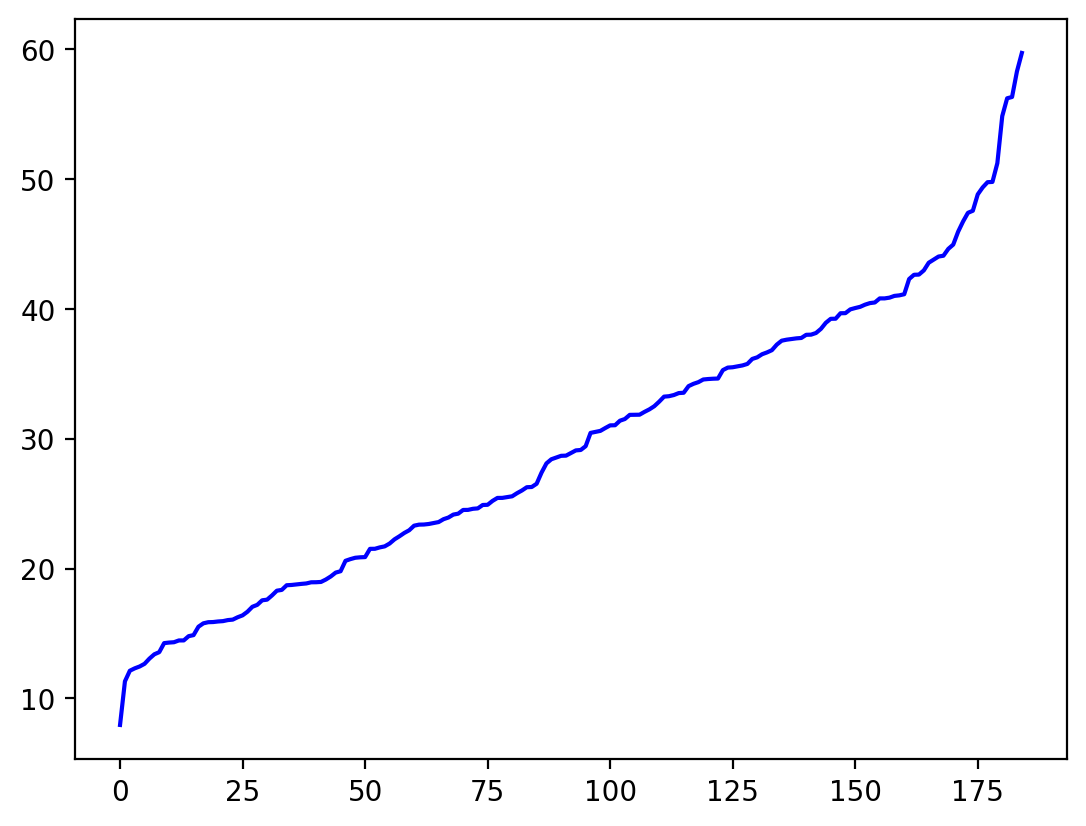

In [337]:
push_data = pd.read_csv('AllQtyDF.csv',sep=";")[['Pseudo','PushName','mass','height','MaxForce', 'PerturbationDuration','Final_CoM_y','angle','StepIndex','Impulse']]
push_data = push_data.loc[push_data['angle']==90]
push_data2 = push_data.loc[push_data['StepIndex']==0]
push_data2=push_data2[['Pseudo','PushName','mass','height','MaxForce', 'PerturbationDuration','Final_CoM_y','Impulse']]
push_data = push_data.loc[push_data['StepIndex']==2]
push_data=push_data[['Pseudo','PushName','mass','height','MaxForce', 'PerturbationDuration','Final_CoM_y','Impulse']]

push_data = push_data.sort_values(by=['Impulse'])
push_data2 = push_data2.sort_values(by=['Impulse'])


push_data.head()

x=[]
for i in range(len(push_data['Impulse'])):
    x.append(i)
plt.plot(x,push_data['Impulse'], 'b', linestyle='-')


In [338]:
print(push_data2)
print(push_data)

       Pseudo PushName  mass  height    MaxForce  PerturbationDuration  \
355  TRB0394A   PL90_2  79.1   1.735   36.239842                 0.525   
348  NIB1194A   PL90_1  86.6   1.820   44.890277                 0.550   
971  TRB0394A   PL90_2  79.1   1.735   39.617614                 0.545   
259  CRR1297A   PL90_2  63.6   1.700   45.291197                 0.550   
875  CRR1297A   PL90_1  63.6   1.700   48.649710                 0.535   
..        ...      ...   ...     ...         ...                   ...   
287  CHA0296A   PM90_2  91.3   1.930   89.915943                 0.830   
251  DER0594A   PM90_2  75.0   1.820   96.079153                 0.860   
868  DER0594A   PM90_2  75.0   1.820   93.591926                 0.830   
286  CHA0296A   PM90_1  91.3   1.930   93.426773                 0.880   
250  DER0594A   PM90_1  75.0   1.820  108.075259                 0.965   

     Final_CoM_y    Impulse  
355     0.096732   7.808794  
348     0.017278   8.628103  
971     0.127955   9.

In [367]:
print(study)
import shutil


for i in range(len(push_data2['Impulse'])):
    
    f = open("resultatTraj.txt", "w")
    f.write('42.37105225248371\n42.05437170004417\n0.2058245166324224\n1.3274185940479835\n1.7961891104626564\n0.27621277854850253' )
    f.write("\n" + str(push_data2['MaxForce'].iloc[i]) + " " + str(push_data2['PerturbationDuration'].iloc[i]) +"\n")
    f.close()

    subprocess.check_call(['../../bin/App_BulletExampleBrowser_vs2010_x64_debug.exe'])
    
    shutil.copyfile('output300.txt', 'Trajectoires/'+str(push_data2['Pseudo'].iloc[i])+'_'+str(push_data2['PushName'].iloc[i])+'.txt')
        
        

       Pseudo PushName  mass  height    MaxForce  PerturbationDuration  \
970  TRB0394A   PL90_1  79.1   1.735   33.205219                 0.560   
864  DEL0696A   PL90_2  67.0   1.770   50.562692                 0.455   
923  MAA0996A   PL90_1  56.7   1.750   42.574038                 0.655   
929  ROM0497A   PL90_1  63.4   1.760   52.136028                 0.545   
935  LIC1296A   PL90_1  62.3   1.635   60.925935                 0.535   
..        ...      ...   ...     ...         ...                   ...   
954  JAL1098A   PH90_1  76.8   1.800  146.605663                 0.770   
901  CHA0296A   PH90_1  91.3   1.930  104.556845                 0.955   
902  CHA0296A   PH90_2  91.3   1.930   94.912567                 0.990   
249  DER0594A   PH90_2  75.0   1.820  134.304916                 0.865   
955  JAL1098A   PH90_2  76.8   1.800  143.867494                 0.820   

     Final_CoM_y    Impulse  
970     0.276960   7.953480  
864     0.129216  11.314134  
923     0.198996  12.

In [344]:
start = 81

study = push_data.iloc[0: len(push_data)]
print(study)

ground_data =push_data.iloc[start]

subjects=[]
simulation=[]
normalize=[]

for i in range(0,len(push_data)):
    subject_data=push_data.iloc[i]
    subjects.append(pd.read_csv('C:/Users/ajensen/Documents/Data_DeCIMo/'+ subject_data['Pseudo']+'NA/Mocap/'+ subject_data['PushName']+'/CSV_export/COM.csv', sep=",",header=None).transpose())
    simulation.append(pd.read_csv('Trajectoires/'+str(subject_data['Pseudo'])+'_'+str(subject_data['PushName'])+'.txt', sep=" "))
    normalize.append([subject_data['height'],subject_data['mass']])
    
ground = pd.read_csv('C:/Users/ajensen/Documents/Data_DeCIMo/'+ ground_data['Pseudo']+'NA/Mocap/'+ ground_data['PushName']+'/CSV_export/COM.csv', sep=",",header=None).transpose()


print(len(subjects))
print(len(simulation))
ground.head()
subject.head()

       Pseudo PushName  mass  height    MaxForce  PerturbationDuration  \
970  TRB0394A   PL90_1  79.1   1.735   33.205219                 0.560   
864  DEL0696A   PL90_2  67.0   1.770   50.562692                 0.455   
923  MAA0996A   PL90_1  56.7   1.750   42.574038                 0.655   
929  ROM0497A   PL90_1  63.4   1.760   52.136028                 0.545   
935  LIC1296A   PL90_1  62.3   1.635   60.925935                 0.535   
..        ...      ...   ...     ...         ...                   ...   
954  JAL1098A   PH90_1  76.8   1.800  146.605663                 0.770   
901  CHA0296A   PH90_1  91.3   1.930  104.556845                 0.955   
902  CHA0296A   PH90_2  91.3   1.930   94.912567                 0.990   
249  DER0594A   PH90_2  75.0   1.820  134.304916                 0.865   
955  JAL1098A   PH90_2  76.8   1.800  143.867494                 0.820   

     Final_CoM_y    Impulse  
970     0.276960   7.953480  
864     0.129216  11.314134  
923     0.198996  12.

,0,1,2
0,0.000000,0.000000,1.021887
1,-0.000009,0.000006,1.021874
2,-0.000018,0.000013,1.021862
3,-0.000027,0.000019,1.021850
4,-0.000036,0.000025,1.021838


In [164]:
from pylab import *
from scipy.signal import savgol_filter

def trajError(ground,subject):
    
    #print(ground)
    #print(subject)
    
    res=0
    
    for col in {1}:
    
        try:
            pic1,_,gpr = findStart(ground[: len(ground) - 150],col)
        except TypeError:
            pic1,_,gpr = 0,_,2

        pic2=200      
        
        if(pic1>=pic2):
            pic1 = pic1-pic2
            pic2=0
        else :
            pic2 = pic2-pic1
            pic1=0
        
        end = min(len(subject)-pic2,len(ground)-pic1)
        

        y=[]
        g2=[]
        for i in range(0,end):
            y.append(subject['Z'].iloc[i+pic2])
            g2.append(ground.iloc[:, col].iloc[i+pic1])
        
        FilteredY = savgol_filter(subject['Z'], 55, 5)
        FDerivY = TemporalDeriv(FilteredY)

        FilteredG = savgol_filter(ground.iloc[:,1], 55, 5)
        FDeriG = TemporalDeriv(FilteredG)
    
        maxY = argmax(FDerivY)
        maxG = argmax(FDeriG)
        if(maxG > (len(FDeriG)-301)):
            maxG= len(FDeriG)-301
        if(maxG > (len(FDerivY)-301)):
            maxG= len(FDerivY)-301
        if(maxG < 301):
            maxG= 301
        if(maxY < 301 ):
            maxY= 301   
            
        y=[]
        for i in range(maxY-300,maxY+300):
            y.append(FDerivY[i])
        g2=[]
        for i in range(maxG-300,maxG+300):
            g2.append(FDeriG[i])  
            
         
            
        #diff = abs(1-(0.2+(y))/(0.2+(g2)))
        diff = pow(2,10*abs(np.array(y)-np.array(g2)))
            
        res+= sum(diff)/len(diff)
        
        x=[]
        for i in range(0,600):
            x.append(i)
        plt.plot(x,diff, 'r', linestyle='-')
        
        
        #print('Colonne ' + str(col) + ' '+ str(sum(diff)/len(diff)) + '\n')
        
        
        
    return res
    

def findStart(ground_1,index):
    x = [0]*(len(ground_1)-1)
    y = [0]*(len(ground_1)-1)
    
    for i in range(0,len(ground_1)-1):
        x[i] = i
        y[i] = 2000*(ground_1.iloc[:,index].iloc[i+1]-ground_1.iloc[:,index].iloc[i])
    
    return(ComputePerturbationDuration(y))

def ComputePerturbationDuration(ForceData,Treshold=0.25):
    """ Return the index of Time at wich the push Start and End"""

    StartIndex = 0
    EndIndex = len(ForceData)-1

    MaxForce = max(ForceData)
    MaxIndex = argmax(ForceData)
    
    ## Filtered Normal Deriv of the force 
    FilteredForce = savgol_filter(ForceData, 55, 5)
    FDeriv = TemporalDeriv(FilteredForce)/max(abs(TemporalDeriv(FilteredForce)))
    
    
      
       
            
    ## Find the first Zero before rising edge
    i = argmax(FDeriv)# rising edge index
    while StartIndex == 0 and i>0:
        if FDeriv[i]<=0.1 and ForceData[i]/max(ForceData)<Treshold:  
            StartIndex = i
        i -= 1
        
    ## Find the first Zero after falling edge
    i = argmin(FDeriv)# rising edge index
    while EndIndex == len(ForceData)-1 and i<len(ForceData)-1:
        if FDeriv[i]>=0.1 and ForceData[i]/max(ForceData)<Treshold:  
            EndIndex = i
        i += 1    
    
    ## Treatment of the no force trial (when the sensor failed)
    if max(ForceData-ForceData[StartIndex])<5:
        StartIndex, EndIndex = 0,1
    
    #print(StartIndex)
    
    return StartIndex, EndIndex , ForceData

def TemporalDeriv(X, dt = 1/200):
    """ 2nd Order time derivative of X. 
        Where X is an array of n dimention*(Nb of frame).
        dt is the duration in seconds of the time step. """
    if len(shape(X))>1: # if X have more than one dimention
        DerivX = zeros(X.shape)
    
        # for the first time iteration a forward 2nd order difference is used
        DerivX[:,0] = (4*X[:,1] - 3*X[:,0] - X[:,2])/(2*dt)
        # for the last time iteration, a backward 2nd order differenece is used
        DerivX[:,-1] = (-4*X[:,-2] + 3*X[:,-1] + X[:,-3])/(2*dt)
    
        # for other time iterations, a central 2nd order difference is used
        for i in range(1, len(X[0])-1):
            DerivX[:,i] = (X[:,i+1]-X[:,i-1])/(2*dt)
    else :
        DerivX = zeros(len(X))
    
        # for the first time iteration a forward 2nd order difference is used
        DerivX[0] = (4*X[1] - 3*X[0] - X[2])/(2*dt)
        # for the last time iteration, a backward 2nd order differenece is used
        DerivX[-1] = (-4*X[-2] + 3*X[-1] + X[-3])/(2*dt)
    
        # for other time iterations, a central 2nd order difference is used
        for i in range(1, len(X)-1):
            DerivX[i] = (X[i+1]-X[i-1])/(2*dt)

    return DerivX

0
0
0
0
0
0
0
0
0
1144
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
1940
0
0
1940
0
1211
1367
0
0
0
0
0
1144
0
0
0
0
1211
0
1627
0
1560
0
0
1336
1336
0
0
0
1560
0
1627
1572
1367
1216
1216
1572
0
0
0
112
110


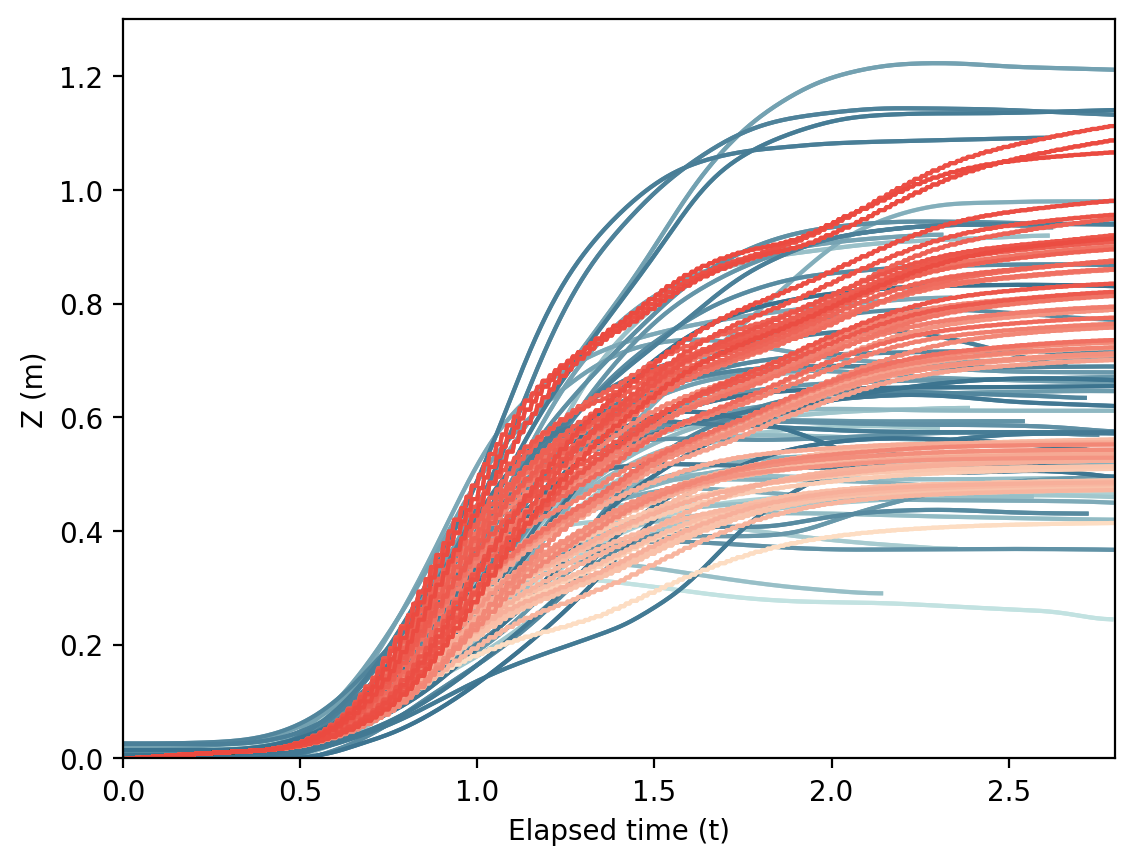

In [456]:
def hex_to_RGB(hex_str):
    """ #FFFFFF -> [255,255,255]"""
    #Pass 16 to the integer function for change of base
    return [int(hex_str[i:i+2], 16) for i in range(1,6,2)]

def get_color_gradient(c1, c2, n):
    """
    Given two hex colors, returns a color gradient
    with n colors.
    """
    assert n > 1
    c1_rgb = np.array(hex_to_RGB(c1))/255
    c2_rgb = np.array(hex_to_RGB(c2))/255
    mix_pcts = [x/(n-1) for x in range(n)]
    rgb_colors = [((1-mix)*c1_rgb + (mix*c2_rgb)) for mix in mix_pcts]
    return rgb_colors

color1 = "#fde0c5"
color2 = "#eb4a40"

color3 = "#d1eeea"
color4 = "#3b738f"


from colour import Color
yel = Color("yellow")
colors = list(yel.range_to(Color("green"),len(subjects)))

red = Color("yellow")
colors2 = list(red.range_to(Color("red"),len(subjects)+1))
pic1,_,_ = findStart(ground,1)



xcor=[]
ycor=[]

xcor2=[]
ycor2=[]

xtemp=[]
ytemp=[]
x0=[]
y0=[]
for i in range(pic1-50,pic1+350):
    if(i%40==0):
        xtemp.append(ground[0].iloc[i])
        ytemp.append(ground[1].iloc[i]* (1 + 0.005*(normalize[81][1]-1.75)) * (1 + 0.003*(normalize[81][0]-70)))
    x0.append(i-pic1+50)
    y0.append(ground[1].iloc[i])
    
#xcor.append(xtemp)
#ycor.append(ytemp)

pushes=[]

def trace_sub(toTrace,norm,i):
    pic2,_,_ = findStart(toTrace,1)
    x=[]
    y=[]
    
    if(len(toTrace)-pic2<100 or pic2<50):
        print(pic2)
        return
    #print(pic2)
    
    pushes.append(i)
    
    xtemp=[]
    ytemp=[]
    for j in range(pic2-50,len(toTrace)):
        if(j%40==0):
            xtemp.append(toTrace[0].iloc[j])
            ytemp.append(toTrace[1].iloc[j] * (1 + 0.005*(norm[1]-1.75)) * (1 + 0.003*(norm[0]-70)))
            
            
            
        x.append((j-pic2+50)/200)
        y.append(toTrace[1].iloc[j] * (1 + 0.005*(norm[1]-1.75)) * (1 + 0.003*(norm[0]-70)))

    plt.plot(x,y, color=get_color_gradient(color3, color4, len(subjects))[i], linestyle='-')
    xcor.append(xtemp)
    ycor.append(ytemp)

for i in range(len(subjects)):
    trace_sub(subjects[i],normalize[i],i) 
    
def trace_sub_simu(toTrace,j):
    x2=[]
    y2=[]
    
    plt.xlabel('Elapsed time (t)')
    plt.ylabel('Z (m)')
    pic2 = 190
    plt.xlim(0,2.8)
    plt.ylim(0,1.3)
    if(toTrace['Z'].iloc[len(toTrace)-1]<0.2):
        return
    xtemp=[]
    ytemp=[]
    for i in range(pic2-50,len(toTrace['X'])):
        if(i%40==0):
            xtemp.append(-toTrace['X'].iloc[i])
            ytemp.append(toTrace['Z'].iloc[i]-0.05)
        x2.append((i-pic2+50)/200)
        y2.append(toTrace['Z'].iloc[i]-0.05)

    plt.plot(x2,y2, color = get_color_gradient(color1, color2, len(pushes))[j], linestyle='-')
    xcor2.append(xtemp)
    ycor2.append(ytemp)

a=0
for i in pushes:
    trace_sub_simu(simulation[i],a) 
    a+=1
print(len(ycor))
print(len(ycor2))

#plt.plot(x0,y0, 'b', linestyle='-')

(1.0, 0.9999999999999998, 0.0)
112
110


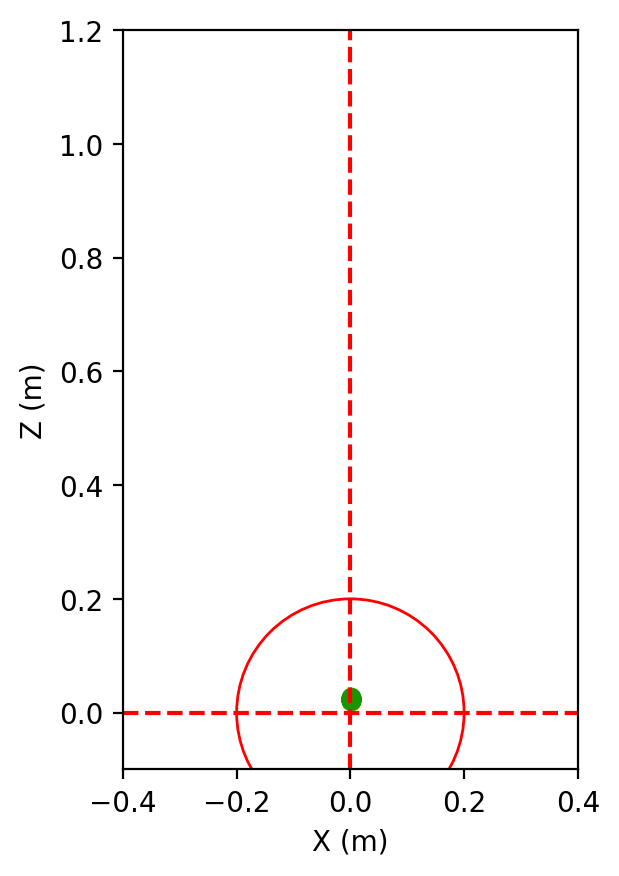

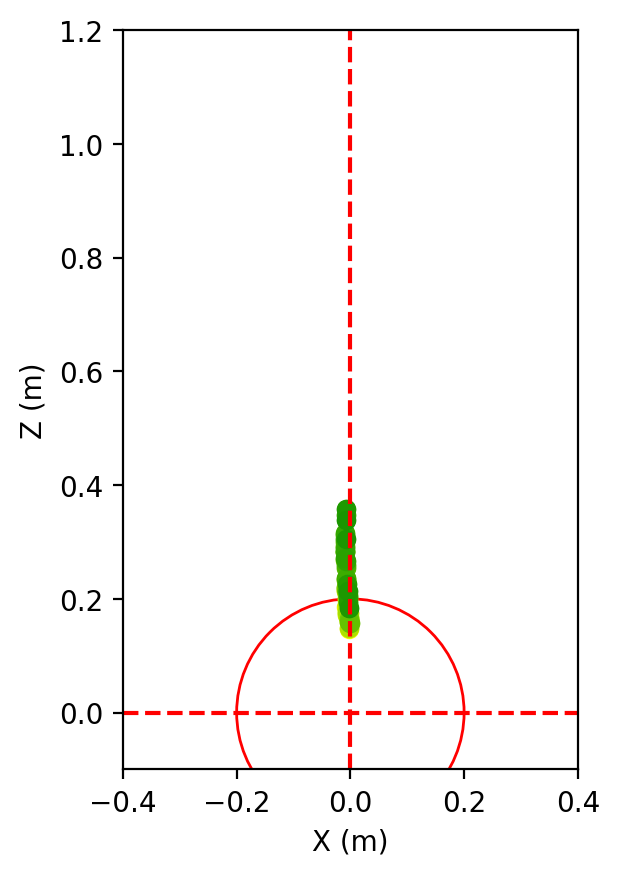

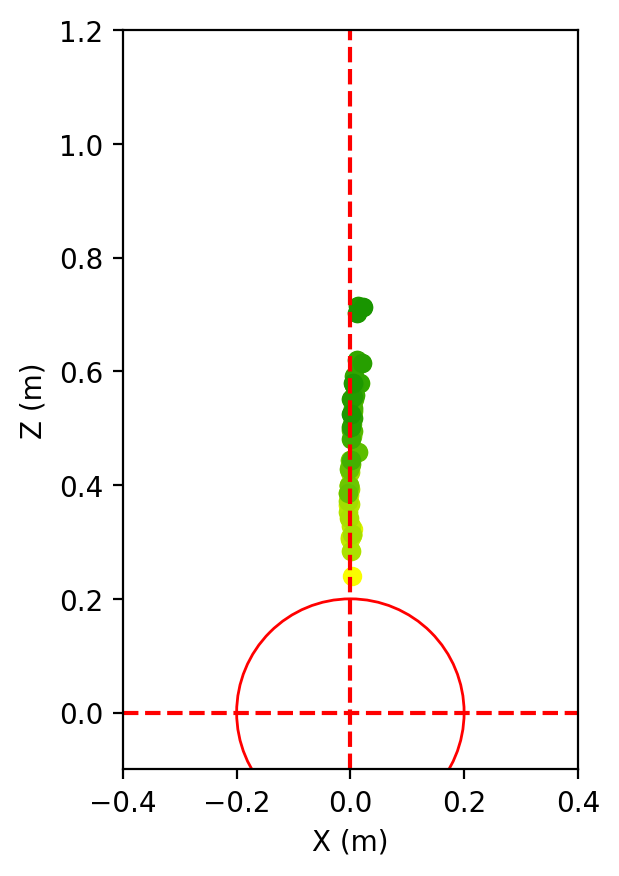

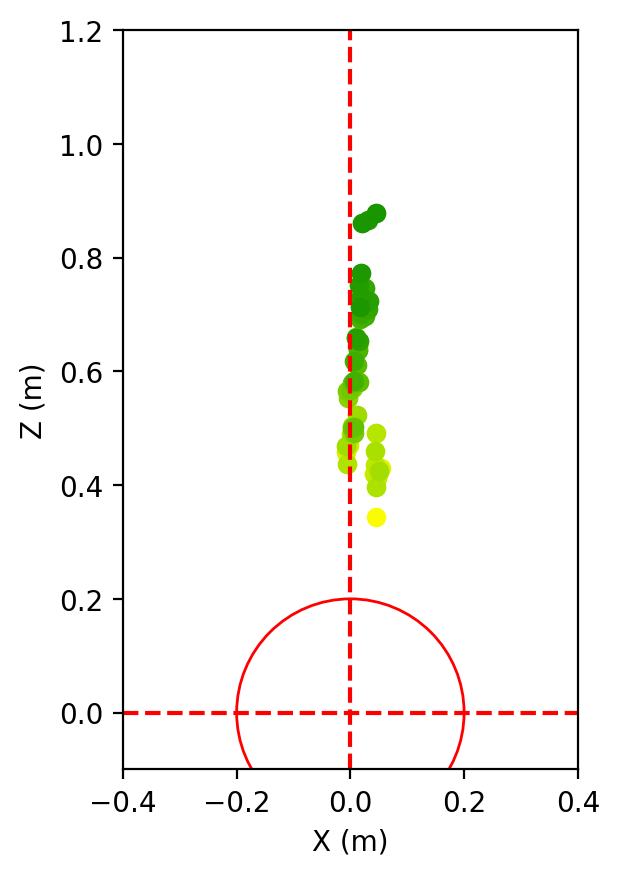

In [393]:
#print(xcor)
%matplotlib inline

from colour import Color
red = Color("yellow")
colors = list(red.range_to(Color("green"),132))

print(colors[0].rgb)

print(len(ycor))
print(len(ycor2))


#plt.title('CoM position of data')

for index in range(1,5):
    index=2*index
    fig = plt.figure()
    plt.xlabel('X (m)')
    plt.ylabel('Z (m)')
    #plt.title('CoM position of data')
    xfin=[]
    yfin=[]
    xfin2=[]
    yfin2=[]
    xfin3=[]
    yfin3=[]
    ax = plt.gca()
    ax.set_aspect('equal', adjustable='box')
    plt.ylim(-0.1,1.2)
    plt.xlim(-0.4,0.4)
    circle2 = plt.Circle((0, 0), 0.2, color='r', fill=False)
    ax.add_patch(circle2)
    ax.axhline(y=0, color='r',linestyle='--')
    ax.axvline(x=0, color='r',linestyle='--')
    
    suj2=xcor2
    suj = ycor2
    for i in range(1,len(suj)):
        plt.scatter(suj2[i][index],suj[i][index], color = colors[i].rgb, linestyle='None',alpha=1.0)
        if(i<len(suj)/3):
            xfin.append(suj2[i][index])
            yfin.append(suj[i][index])
        else:
            if(i<2*len(suj)/3):
                xfin2.append(suj2[i][index])
                yfin2.append(suj[i][index])
            else:
                xfin3.append(suj2[i][index])
                yfin3.append(suj[i][index])
    
    #plt.plot(xfin2,yfin2, 'go', linestyle='None',alpha=0.5)
    
    fig.savefig('trajres/sim'+str(index)+'.png',bbox_inches = 'tight')

    

185


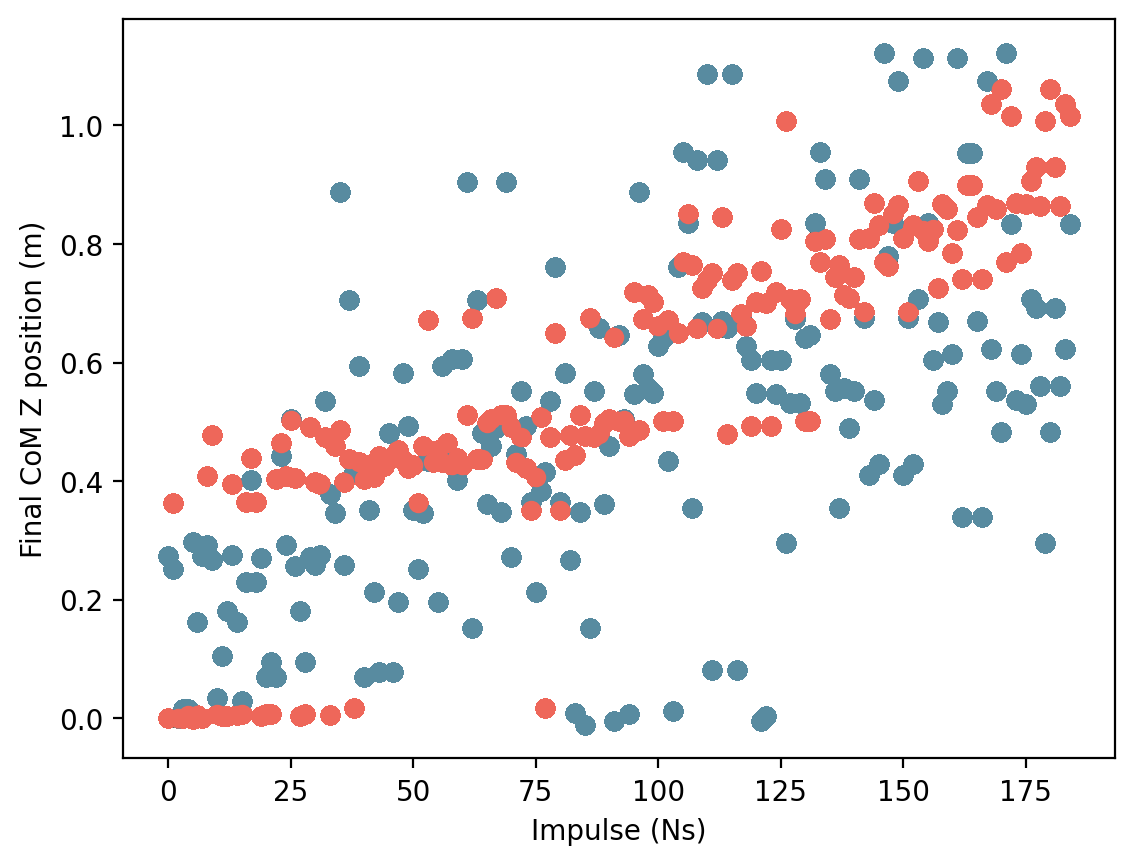

In [466]:
zdata=[]
zsimu=[]
x=[]

from colour import Color
red = Color("yellow")
colors = list(red.range_to(Color("green"),len(subjects)))

for i in range(len(subjects)):
    x.append(i)
    zdata.append(subjects[i].iloc[-1].iloc[1]* (1 + 0.015*(normalize[i][1]-1.75)) * (1 + 0.007*(normalize[i][0]-70)))
    zsimu.append(simulation[i]['Z'].iloc[-1]-0.1)
 
print(len(subjects))

#plt.title("Simulation (blue) and data (orange) comparison of traveled distance in the direction of the push by impulse")
plt.xlabel('Impulse (Ns)')
plt.ylabel('Final CoM Z position (m)')
#plt.ylim(0,1.2)
#plt.xlim(0,1.2)
#plt.plot([0, 1.2], [0, 1.2], 'r--', lw=2)
for i in range(1,len(subjects)):
    #plt.scatter(zdata[i],zsimu[i], color = colors[i].rgb, linestyle='None',alpha=1.0)    
    plt.scatter(x,zdata, color = get_color_gradient(color3, color4, 100)[80], linestyle='None',alpha=1.0)
    plt.scatter(x,zsimu, color = get_color_gradient(color1, color2, 100)[80], linestyle='None',alpha=1.0)

    


In [368]:
subjects2=[]
simulation2=[]

for i in range(0,len(push_data)):
    subject_data=push_data.iloc[i]
    subjects2.append(pd.read_csv('C:/Users/ajensen/Documents/Data_DeCIMo/'+ subject_data['Pseudo']+'NA/Mocap/'+ subject_data['PushName']+'/CSV_export/COM.csv', sep=",",header=None).transpose())
    simulation2.append(pd.read_csv('Trajectoires/'+str(subject_data['Pseudo'])+'_'+str(subject_data['PushName'])+'.txt', sep=" "))

for i in range(0,len(push_data2)):
    subject_data=push_data2.iloc[i]
    subjects2.append(pd.read_csv('C:/Users/ajensen/Documents/Data_DeCIMo/'+ subject_data['Pseudo']+'NA/Mocap/'+ subject_data['PushName']+'/CSV_export/COM.csv', sep=",",header=None).transpose())
    simulation2.append(pd.read_csv('Trajectoires/'+str(subject_data['Pseudo'])+'_'+str(subject_data['PushName'])+'.txt', sep=" "))
    
print(len(subjects2))
print(len(simulation2))

251
251


In [384]:
faux_neg = 0
for i in range(0,len(push_data)):
    if(simulation2[i]['pasEffectue'].iloc[-1]==0):
        faux_neg += 1
print(faux_neg)
print(len(push_data)-faux_neg)

faux_pos = 0
for i in range(0,len(push_data2)):
    if(simulation2[len(push_data)+i]['pasEffectue'].iloc[-1]):
        faux_pos += 1
print(faux_pos)
print(len(push_data2)-faux_pos)

22
163
38
28
